# German MLM Curriculum MVP — Colab Stable Version

**Project:** Easy-to-Hard German Continued Pretraining for a Small English MLM  
**Core comparison:** Mixed German4All training vs Easy → Medium → Hard curriculum training.

This notebook is designed to avoid the previous German4All loading failure by using the same main-only loading strategy that passed the smoke test:

- no Hugging Face dataset builder;
- no Dataset object conversion;
- no torch formatting of dataset tables;
- one explicitly selected German4All main CSV loaded with pandas.

The model is `prajjwal1/bert-tiny`; the tokenizer is `bert-base-uncased`. The tokenizer mismatch is intentional: this is continued pretraining from a small English MLM into German, not training a native German model.


## 1. Configuration

Change only this cell for a pilot run or a longer run. For Colab free GPU, start with the default pilot settings. For a more serious run, increase `total_steps` to `1500` or `3000` and set `max_eval_batches = None`.


In [70]:
from dataclasses import dataclass
from pathlib import Path

@dataclass
class CFG:
    # German4All repository
    repo_id: str = "tum-nlp/German4All-Corpus"
    repo_type: str = "dataset"
    manual_filename: str | None = None  # e.g. "main/train.csv" if automatic discovery fails

    # Model and tokenizer
    model_name: str = "prajjwal1/bert-tiny"
    tokenizer_name: str = "bert-base-uncased"

    # Data split
    seed: int = 42
    validation_fraction: float = 0.10
    min_validation_rows: int = 200
    max_raw_rows: int | None = None  # set a small number only for debugging

    # MLM setup
    mlm_probability: float = 0.15
    max_length: int = 128

    # Training setup
    total_steps: int = 900      # pilot; try 1500 or 3000 later
    eval_steps: int = 100
    save_steps: int = 100
    train_log_steps: int = 10
    batch_size: int = 8
    eval_batch_size: int = 16
    learning_rate: float = 5e-5
    weight_decay: float = 0.01
    max_grad_norm: float = 1.0
    use_amp: bool = True

    # Evaluation speed control
    max_eval_batches: int | None = 30  # set None for full validation evaluation

    # Output and resume
    use_google_drive: bool = False
    local_output_dir: str = "/content/german_mlm_curriculum_mvp_outputs"
    drive_output_dir: str = "/content/drive/MyDrive/german_mlm_curriculum_mvp_outputs"
    overwrite_outputs: bool = False
    resume: bool = True

cfg = CFG()
print(cfg)


CFG(repo_id='tum-nlp/German4All-Corpus', repo_type='dataset', manual_filename=None, model_name='prajjwal1/bert-tiny', tokenizer_name='bert-base-uncased', seed=42, validation_fraction=0.1, min_validation_rows=200, max_raw_rows=None, mlm_probability=0.15, max_length=128, total_steps=900, eval_steps=100, save_steps=100, train_log_steps=10, batch_size=8, eval_batch_size=16, learning_rate=5e-05, weight_decay=0.01, max_grad_norm=1.0, use_amp=True, max_eval_batches=None, use_google_drive=False, local_output_dir='/content/german_mlm_curriculum_mvp_outputs', drive_output_dir='/content/drive/MyDrive/german_mlm_curriculum_mvp_outputs', overwrite_outputs=False, resume=True)


## 2. Environment setup

This cell only installs missing lightweight packages. It does not upgrade Torch, CUDA, NumPy, or other core Colab dependencies.


In [71]:
import importlib.util
import subprocess
import sys

print("Python:", sys.version)

missing = []
for import_name, pip_name in [
    ("huggingface_hub", "huggingface_hub"),
    ("transformers", "transformers"),
    ("pandas", "pandas"),
    ("sklearn", "scikit-learn"),
    ("matplotlib", "matplotlib"),
]:
    if importlib.util.find_spec(import_name) is None:
        missing.append(pip_name)

if missing:
    print("Installing missing lightweight packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Required packages already available.")

print("datasets loaded?", "datasets" in sys.modules)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Required packages already available.
datasets loaded? False


In [72]:
import csv
import json
import math
import os
import random
import shutil
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import DataLoader, Dataset

from huggingface_hub import hf_hub_download, list_repo_files
from transformers import AutoTokenizer, DataCollatorForLanguageModeling
from transformers import BertConfig, BertForMaskedLM

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("datasets loaded?", "datasets" in sys.modules)


Torch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
datasets loaded? False


In [73]:
def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_all_seeds(cfg.seed)

def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat(timespec="seconds")

def assert_hf_dataset_builder_not_loaded(stage: str):
    loaded = "datasets" in sys.modules
    print(f"[{stage}] datasets loaded?", loaded)
    if loaded:
        raise RuntimeError(
            "The Hugging Face dataset builder package is loaded in this runtime. "
            "Restart the runtime and run this notebook from the first cell."
        )

assert_hf_dataset_builder_not_loaded("before data loading")


[before data loading] datasets loaded? False


## 3. Output directory

For interruption-safe training, set `cfg.use_google_drive = True` in the configuration cell before running this notebook.


In [74]:
if cfg.use_google_drive:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        raise RuntimeError("Google Drive mounting failed. Set cfg.use_google_drive=False or fix Drive access.") from exc
    OUTPUT_DIR = Path(cfg.drive_output_dir)
else:
    OUTPUT_DIR = Path(cfg.local_output_dir)

if cfg.overwrite_outputs and OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
LOG_DIR = OUTPUT_DIR / "logs"
PLOT_DIR = OUTPUT_DIR / "plots"
for d in [CHECKPOINT_DIR, LOG_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EVAL_LOG_PATH = LOG_DIR / "eval_log.csv"
TRAIN_LOG_PATH = LOG_DIR / "train_log.csv"

print("OUTPUT_DIR:", OUTPUT_DIR)
print("EVAL_LOG_PATH:", EVAL_LOG_PATH)
print("TRAIN_LOG_PATH:", TRAIN_LOG_PATH)


OUTPUT_DIR: /content/german_mlm_curriculum_mvp_outputs
EVAL_LOG_PATH: /content/german_mlm_curriculum_mvp_outputs/logs/eval_log.csv
TRAIN_LOG_PATH: /content/german_mlm_curriculum_mvp_outputs/logs/train_log.csv


## 4. Load German4All main corpus with pandas

This is the exact safety principle from the smoke test: list CSV files, avoid corrected/annotated subsets, download one main-like CSV, and read it with pandas.


In [75]:
REQUIRED_CL_COLS = ["cl_1", "cl_2", "cl_3", "cl_4", "cl_5"]
EXCLUDED_PATH_PARTS = {"corrected", "annotated"}

repo_files = list_repo_files(cfg.repo_id, repo_type=cfg.repo_type)
csv_files = sorted([f for f in repo_files if f.lower().endswith(".csv")])

print("CSV files found:")
for f in csv_files:
    print(" -", f)

if cfg.manual_filename is not None:
    candidates = [cfg.manual_filename]
else:
    candidates = []
    for f in csv_files:
        parts = set(Path(f).parts)
        if parts.isdisjoint(EXCLUDED_PATH_PARTS):
            candidates.append(f)

    def candidate_score(filename: str) -> tuple:
        lower = filename.lower()
        score = 0
        if "main" in lower:
            score -= 20
        if lower.endswith("train.csv"):
            score -= 10
        if filename == "main/train.csv":
            score -= 100
        return (score, filename)

    candidates = sorted(candidates, key=candidate_score)

print("\nCandidate CSV files:")
for f in candidates:
    print(" -", f)

if not candidates:
    raise FileNotFoundError("No main-like CSV candidates found. Set cfg.manual_filename manually.")


CSV files found:
 - annotated/test.csv
 - annotated/train.csv
 - annotated/val.csv
 - corrected/test.csv
 - corrected/train.csv
 - corrected/val.csv
 - main-old/train.csv
 - main/train.csv

Candidate CSV files:
 - main/train.csv
 - main-old/train.csv


In [76]:
selected_filename = None
selected_local_path = None
candidate_header_info = []

for filename in candidates:
    print(f"\nInspecting candidate: {filename}")
    try:
        local_path = hf_hub_download(
            repo_id=cfg.repo_id,
            repo_type=cfg.repo_type,
            filename=filename,
        )
        header_df = pd.read_csv(local_path, nrows=1)
        columns = list(header_df.columns)
        has_required = all(col in columns for col in REQUIRED_CL_COLS)
        candidate_header_info.append({
            "filename": filename,
            "num_columns": len(columns),
            "has_required_cl_columns": has_required,
            "columns": columns,
        })
        print("Columns:", columns)
        print("Has cl_1...cl_5?", has_required)
        if has_required:
            selected_filename = filename
            selected_local_path = local_path
            break
    except Exception as exc:
        print("Failed candidate:", repr(exc))

if selected_filename is None:
    print("Candidate header info:")
    for item in candidate_header_info:
        print(item["filename"], item["has_required_cl_columns"], item["columns"])
    raise RuntimeError(
        "Could not find a CSV with cl_1...cl_5. Set cfg.manual_filename to the main corpus CSV path printed above."
    )

print("\nSelected German4All CSV:", selected_filename)
print("Local path:", selected_local_path)
assert_hf_dataset_builder_not_loaded("after selecting CSV")



Inspecting candidate: main/train.csv
Columns: ['id', 'title', 'text', 'url', 'wiki_id', 'views', 'paragraph_id', 'langs', 'text_length', 'word_count', 'prompt_token_count', 'cl_1', 'cl_2', 'cl_3', 'cl_4', 'cl_5']
Has cl_1...cl_5? True

Selected German4All CSV: main/train.csv
Local path: /root/.cache/huggingface/hub/datasets--tum-nlp--German4All-Corpus/snapshots/bd8cca756544230d11caa4b34032dbc841d052a4/main/train.csv
[after selecting CSV] datasets loaded? False


In [77]:
df = pd.read_csv(selected_local_path)

print("Dataset object:", type(df))
print("Shape:", df.shape)
print("Column names:")
print(list(df.columns))
print("\nOne raw sample:")
display(df.iloc[0].to_frame("value"))

missing_cols = [c for c in REQUIRED_CL_COLS if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required German4All columns: {missing_cols}")

if cfg.max_raw_rows is not None:
    df = df.sample(n=min(cfg.max_raw_rows, len(df)), random_state=cfg.seed).reset_index(drop=True)
    print("Debug sample applied. New shape:", df.shape)

assert_hf_dataset_builder_not_loaded("after pandas read_csv")


Dataset object: <class 'pandas.core.frame.DataFrame'>
Shape: (25459, 16)
Column names:
['id', 'title', 'text', 'url', 'wiki_id', 'views', 'paragraph_id', 'langs', 'text_length', 'word_count', 'prompt_token_count', 'cl_1', 'cl_2', 'cl_3', 'cl_4', 'cl_5']

One raw sample:


,value
id,1525353
title,Initiative Neue Soziale Marktwirtschaft
text,Gemeinsam mit der Zeitung Die Welt organisiert...
url,https://de.wikipedia.org/wiki?curid=466733
wiki_id,466733
views,461.671539
paragraph_id,24
langs,1
text_length,183
word_count,24


[after pandas read_csv] datasets loaded? False


## 5. Row-level split and difficulty expansion

Validation is split before expanding `cl_1`–`cl_5`. This reduces leakage where different difficulty versions of the same source paragraph appear in both training and validation.

Mapping:

| Group | German4All columns |
|---|---|
| easy | `cl_1`, `cl_2` |
| medium | `cl_3` |
| hard | `cl_4`, `cl_5` |


In [78]:
df_clean = df.copy()

for col in REQUIRED_CL_COLS:
    df_clean[col] = df_clean[col].astype("string")

valid_mask = pd.Series(True, index=df_clean.index)
for col in REQUIRED_CL_COLS:
    valid_mask &= df_clean[col].notna()
    valid_mask &= df_clean[col].str.strip().ne("")

num_invalid = int((~valid_mask).sum())
if num_invalid > 0:
    print(f"Dropping {num_invalid} rows with missing or empty cl_1...cl_5 values.")

df_clean = df_clean.loc[valid_mask].reset_index(drop=True)

val_rows = max(cfg.min_validation_rows, int(len(df_clean) * cfg.validation_fraction))
val_rows = min(val_rows, max(1, len(df_clean) - 1))

row_indices = np.arange(len(df_clean))
train_idx, val_idx = train_test_split(
    row_indices,
    test_size=val_rows,
    random_state=cfg.seed,
    shuffle=True,
)

train_rows = df_clean.iloc[train_idx].reset_index(drop=True)
val_rows_df = df_clean.iloc[val_idx].reset_index(drop=True)

print("Clean raw rows:", len(df_clean))
print("Train raw rows:", len(train_rows))
print("Validation raw rows:", len(val_rows_df))


Clean raw rows: 25459
Train raw rows: 22914
Validation raw rows: 2545


In [79]:
LEVEL_MAPPING = {
    "easy": ["cl_1", "cl_2"],
    "medium": ["cl_3"],
    "hard": ["cl_4", "cl_5"],
}


def expand_rows(rows: pd.DataFrame, split_name: str) -> pd.DataFrame:
    records = []
    for source_row_id, row in rows.reset_index(drop=True).iterrows():
        source_id = row.get("id", source_row_id)
        paragraph_id = row.get("paragraph_id", source_row_id)
        title = row.get("title", "")
        for difficulty, cols in LEVEL_MAPPING.items():
            for col in cols:
                text = str(row[col]).strip()
                if text:
                    records.append({
                        "split": split_name,
                        "difficulty": difficulty,
                        "level_column": col,
                        "source_row_id": int(source_row_id),
                        "source_id": source_id,
                        "paragraph_id": paragraph_id,
                        "title": title,
                        "text": text,
                    })
    return pd.DataFrame.from_records(records)

train_examples_df = expand_rows(train_rows, "train")
val_examples_df = expand_rows(val_rows_df, "validation")

print("Train examples:", len(train_examples_df))
print("Validation examples:", len(val_examples_df))
print("\nTrain difficulty counts:")
print(train_examples_df["difficulty"].value_counts().sort_index())
print("\nValidation difficulty counts:")
print(val_examples_df["difficulty"].value_counts().sort_index())

print("\nOne expanded training example:")
display(train_examples_df.head(1).T)


Train examples: 114570
Validation examples: 12725

Train difficulty counts:
difficulty
easy      45828
hard      45828
medium    22914
Name: count, dtype: int64

Validation difficulty counts:
difficulty
easy      5090
hard      5090
medium    2545
Name: count, dtype: int64

One expanded training example:


,0
split,train
difficulty,easy
level_column,cl_1
source_row_id,0
source_id,1896261
paragraph_id,2
title,Doppelrahmkäse
text,In Amerika isst man oft einen weichen Käse. Er...


,split,difficulty,num_examples
0,train,easy,45828
1,train,medium,22914
2,train,hard,45828
3,validation,easy,5090
4,validation,medium,2545
5,validation,hard,5090


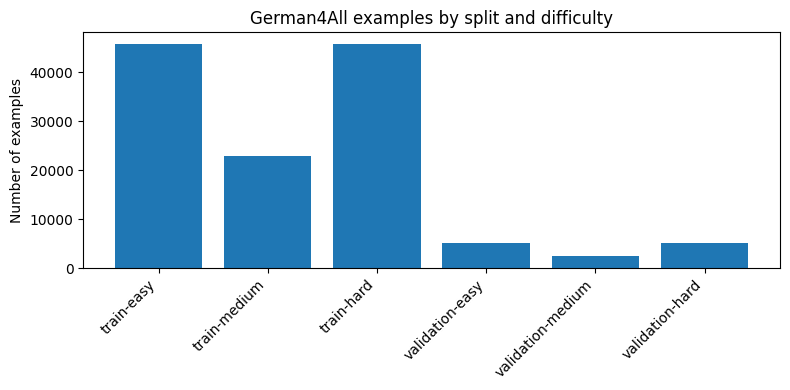

In [80]:
size_rows = []
for split_name, examples in [("train", train_examples_df), ("validation", val_examples_df)]:
    counts = examples["difficulty"].value_counts().to_dict()
    for difficulty in ["easy", "medium", "hard"]:
        size_rows.append({
            "split": split_name,
            "difficulty": difficulty,
            "num_examples": int(counts.get(difficulty, 0)),
        })

size_df = pd.DataFrame(size_rows)
display(size_df)

plt.figure(figsize=(8, 4))
labels = [f"{r.split}-{r.difficulty}" for r in size_df.itertuples()]
plt.bar(labels, size_df["num_examples"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of examples")
plt.title("German4All examples by split and difficulty")
plt.tight_layout()
plt.savefig(PLOT_DIR / "dataset_size_bar_chart.png", dpi=150)
plt.show()


In [81]:
DATA_DIR = OUTPUT_DIR / "prepared_data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
train_examples_df.to_csv(DATA_DIR / "train_examples.csv", index=False)
val_examples_df.to_csv(DATA_DIR / "validation_examples.csv", index=False)
size_df.to_csv(DATA_DIR / "dataset_sizes.csv", index=False)
print("Prepared data saved to:", DATA_DIR)


Prepared data saved to: /content/german_mlm_curriculum_mvp_outputs/prepared_data


## 6. Tokenizer, collator, and model

The tokenizer is English uncased BERT. This creates a limitation for German, especially capitalization and compounds, but it is part of the cross-lingual adaptation setup.


In [82]:
tokenizer = AutoTokenizer.from_pretrained(cfg.tokenizer_name, use_fast=True)
collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=cfg.mlm_probability,
)

print("Tokenizer vocab size:", len(tokenizer))
print("Mask token:", tokenizer.mask_token)
print("datasets loaded?", "datasets" in sys.modules)


Tokenizer vocab size: 30522
Mask token: [MASK]
datasets loaded? False


In [83]:
class TextMLMDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length: int):
        self.texts = [str(t) for t in texts if str(t).strip()]
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding=False,
            return_special_tokens_mask=True,
        )

train_texts_by_split = {
    difficulty: train_examples_df.loc[train_examples_df["difficulty"] == difficulty, "text"].tolist()
    for difficulty in ["easy", "medium", "hard"]
}
train_texts_by_split["mixed"] = train_examples_df["text"].tolist()

val_texts_by_split = {
    difficulty: val_examples_df.loc[val_examples_df["difficulty"] == difficulty, "text"].tolist()
    for difficulty in ["easy", "medium", "hard"]
}
val_texts_by_split["overall"] = val_examples_df["text"].tolist()

train_datasets = {
    name: TextMLMDataset(texts, tokenizer, cfg.max_length)
    for name, texts in train_texts_by_split.items()
}
val_datasets = {
    name: TextMLMDataset(texts, tokenizer, cfg.max_length)
    for name, texts in val_texts_by_split.items()
}

for name, ds in train_datasets.items():
    print(f"train/{name}:", len(ds))
for name, ds in val_datasets.items():
    print(f"validation/{name}:", len(ds))


train/easy: 45828
train/medium: 22914
train/hard: 45828
train/mixed: 114570
validation/easy: 5090
validation/medium: 2545
validation/hard: 5090
validation/overall: 12725


In [84]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = bool(cfg.use_amp and torch.cuda.is_available())
print("Device:", device)
print("AMP enabled:", use_amp)


def create_fresh_model():
    config = BertConfig.from_pretrained(cfg.model_name)
    model = BertForMaskedLM.from_pretrained(cfg.model_name, config=config)
    current_vocab_size = model.get_input_embeddings().num_embeddings
    tokenizer_vocab_size = len(tokenizer)
    print("Model embedding vocab size:", current_vocab_size)
    print("Tokenizer vocab size:", tokenizer_vocab_size)
    if current_vocab_size != tokenizer_vocab_size:
        print("Resizing token embeddings to match tokenizer.")
        model.resize_token_embeddings(tokenizer_vocab_size)
    return model

# Lightweight load test. Training functions create their own model instances.
_tmp_model = create_fresh_model()
print("Model class:", type(_tmp_model))
del _tmp_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Device: cuda
AMP enabled: True


Loading weights:   0%|          | 0/44 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: prajjwal1/bert-tiny
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model embedding vocab size: 30522
Tokenizer vocab size: 30522
Model class: <class 'transformers.models.bert.modeling_bert.BertForMaskedLM'>


## 7. Logging and checkpoints

Each condition has its own checkpoint directory. Logs use a fixed CSV schema:

- Evaluation: `condition, step, phase, eval_split, eval_loss, timestamp`
- Training: `condition, step, phase, train_loss, timestamp`


In [85]:
EVAL_FIELDS = ["condition", "step", "phase", "eval_split", "eval_loss", "timestamp"]
TRAIN_FIELDS = ["condition", "step", "phase", "train_loss", "timestamp"]


def append_csv_row(path: Path, fieldnames: list[str], row: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    exists = path.exists()
    safe_row = {field: row.get(field, None) for field in fieldnames}
    with path.open("a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not exists:
            writer.writeheader()
        writer.writerow(safe_row)


def condition_dir(condition: str) -> Path:
    d = CHECKPOINT_DIR / condition
    d.mkdir(parents=True, exist_ok=True)
    return d


def latest_pointer_path(condition: str) -> Path:
    return condition_dir(condition) / "latest_checkpoint.txt"


def checkpoint_step_dir(condition: str, step: int) -> Path:
    return condition_dir(condition) / f"checkpoint_step_{step:06d}"


def save_checkpoint(condition: str, model, tokenizer, optimizer, step: int, phase: str):
    ckpt_dir = checkpoint_step_dir(condition, step)
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(ckpt_dir)
    tokenizer.save_pretrained(ckpt_dir)
    torch.save(optimizer.state_dict(), ckpt_dir / "optimizer.pt")
    meta = {
        "condition": condition,
        "global_step": int(step),
        "phase": phase,
        "timestamp": utc_now(),
        "model_name": cfg.model_name,
        "tokenizer_name": cfg.tokenizer_name,
        "mlm_probability": cfg.mlm_probability,
        "max_length": cfg.max_length,
        "total_steps": cfg.total_steps,
    }
    with (ckpt_dir / "training_state.json").open("w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)
    latest_pointer_path(condition).write_text(str(ckpt_dir), encoding="utf-8")
    print(f"Saved checkpoint: {ckpt_dir}")


def find_latest_checkpoint(condition: str) -> Path | None:
    pointer = latest_pointer_path(condition)
    if pointer.exists():
        candidate = Path(pointer.read_text(encoding="utf-8").strip())
        if candidate.exists():
            return candidate
    candidates = sorted(condition_dir(condition).glob("checkpoint_step_*"))
    if candidates:
        return candidates[-1]
    return None


def load_or_create_model_and_optimizer(condition: str):
    ckpt = find_latest_checkpoint(condition) if cfg.resume else None
    if ckpt is not None:
        print(f"Resuming {condition} from {ckpt}")
        config = BertConfig.from_pretrained(cfg.model_name)
        model = BertForMaskedLM.from_pretrained(str(ckpt), config=config)
        model.to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
        optimizer_state_path = ckpt / "optimizer.pt"
        if optimizer_state_path.exists():
            optimizer.load_state_dict(torch.load(optimizer_state_path, map_location=device))
        meta_path = ckpt / "training_state.json"
        if meta_path.exists():
            meta = json.loads(meta_path.read_text(encoding="utf-8"))
            start_step = int(meta.get("global_step", 0))
        else:
            start_step = int(ckpt.name.split("_")[-1])
        return model, optimizer, start_step

    print(f"Starting {condition} from scratch.")
    model = create_fresh_model()
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    return model, optimizer, 0


## 8. Evaluation helpers

Validation loss is computed for easy, medium, hard, and overall splits. The same validation split is used for both training conditions.


In [86]:
SPLIT_SEED_OFFSET = {"easy": 11, "medium": 22, "hard": 33, "overall": 44}


def make_loader(dataset, batch_size: int, shuffle: bool, seed: int):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collator,
        generator=generator,
    )


def infinite_batches(dataset, batch_size: int, seed: int):
    epoch = 0
    while True:
        loader = make_loader(dataset, batch_size=batch_size, shuffle=True, seed=seed + epoch)
        for batch in loader:
            yield batch
        epoch += 1


def move_batch_to_device(batch):
    return {k: v.to(device) for k, v in batch.items()}


@torch.no_grad()
def evaluate_dataset(model, dataset, split_name: str, step: int):
    model.eval()
    eval_seed = cfg.seed + 100_000 + step * 10 + SPLIT_SEED_OFFSET[split_name]
    set_all_seeds(eval_seed)
    loader = make_loader(dataset, batch_size=cfg.eval_batch_size, shuffle=False, seed=eval_seed)
    total_loss = 0.0
    total_examples = 0
    used_batches = 0

    for batch_idx, batch in enumerate(loader):
        if cfg.max_eval_batches is not None and batch_idx >= cfg.max_eval_batches:
            break
        batch = move_batch_to_device(batch)
        outputs = model(**batch)
        loss = outputs.loss
        if not torch.isfinite(loss):
            continue
        batch_size = int(batch["input_ids"].shape[0])
        total_loss += float(loss.item()) * batch_size
        total_examples += batch_size
        used_batches += 1

    if total_examples == 0:
        raise RuntimeError(f"No valid evaluation batches for split: {split_name}")

    return total_loss / total_examples, total_examples, used_batches


def evaluate_all_splits(model, condition: str, step: int, phase: str):
    results = []
    for split_name in ["easy", "medium", "hard"]:
        loss, n, batches = evaluate_dataset(model, val_datasets[split_name], split_name, step)
        row = {
            "condition": condition,
            "step": int(step),
            "phase": phase,
            "eval_split": split_name,
            "eval_loss": float(loss),
            "timestamp": utc_now(),
        }
        append_csv_row(EVAL_LOG_PATH, EVAL_FIELDS, row)
        results.append((split_name, loss, n, batches))

    overall_loss, overall_n, overall_batches = evaluate_dataset(model, val_datasets["overall"], "overall", step)
    row = {
        "condition": condition,
        "step": int(step),
        "phase": phase,
        "eval_split": "overall",
        "eval_loss": float(overall_loss),
        "timestamp": utc_now(),
    }
    append_csv_row(EVAL_LOG_PATH, EVAL_FIELDS, row)
    results.append(("overall", overall_loss, overall_n, overall_batches))

    print(f"\nEvaluation | condition={condition} step={step} phase={phase}")
    for split_name, loss, n, batches in results:
        print(f"  {split_name:>7}: loss={loss:.4f} examples={n} batches={batches}")
    model.train()


## 9. Training loop

**Mixed baseline:** all easy, medium, and hard training examples are sampled together for the whole run.

**Easy → Medium → Hard curriculum:** the run is divided into three equal step ranges. The model sees easy examples first, then medium examples, then hard examples.


In [87]:
def curriculum_phase_for_step(step: int) -> str:
    base = cfg.total_steps // 3
    remainder = cfg.total_steps - base * 3
    easy_end = base
    medium_end = base * 2
    hard_end = cfg.total_steps
    if remainder >= 1:
        hard_end = cfg.total_steps
    if step <= easy_end:
        return "easy"
    if step <= medium_end:
        return "medium"
    return "hard"


def phase_for_condition(condition: str, step: int) -> str:
    if condition == "mixed":
        return "mixed"
    if condition == "curriculum":
        return curriculum_phase_for_step(step)
    raise ValueError(f"Unknown condition: {condition}")

print("Curriculum schedule check:")
for s in [1, cfg.total_steps // 3, cfg.total_steps // 3 + 1, 2 * cfg.total_steps // 3, 2 * cfg.total_steps // 3 + 1, cfg.total_steps]:
    if 1 <= s <= cfg.total_steps:
        print(s, "->", curriculum_phase_for_step(s))


Curriculum schedule check:
1 -> easy
300 -> easy
301 -> medium
600 -> medium
601 -> hard
900 -> hard


In [88]:
def train_condition(condition: str):
    assert condition in {"mixed", "curriculum"}
    model, optimizer, start_step = load_or_create_model_and_optimizer(condition)

    if start_step >= cfg.total_steps:
        print(f"{condition} already reached cfg.total_steps={cfg.total_steps}. Skipping training.")
        return

    iterators = {
        "mixed": infinite_batches(train_datasets["mixed"], cfg.batch_size, cfg.seed + 100),
        "easy": infinite_batches(train_datasets["easy"], cfg.batch_size, cfg.seed + 200),
        "medium": infinite_batches(train_datasets["medium"], cfg.batch_size, cfg.seed + 300),
        "hard": infinite_batches(train_datasets["hard"], cfg.batch_size, cfg.seed + 400),
    }

    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    model.train()

    print(f"\n=== Training condition: {condition} ===")
    print("Start step:", start_step)
    print("Target total steps:", cfg.total_steps)

    for step in range(start_step + 1, cfg.total_steps + 1):
        phase = phase_for_condition(condition, step)
        batch = next(iterators[phase])
        batch = move_batch_to_device(batch)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(**batch)
            loss = outputs.loss

        if not torch.isfinite(loss):
            print(f"Skipping non-finite loss at step {step}: {loss}")
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
        scaler.step(optimizer)
        scaler.update()

        if step % cfg.train_log_steps == 0 or step == 1:
            row = {
                "condition": condition,
                "step": int(step),
                "phase": phase,
                "train_loss": float(loss.item()),
                "timestamp": utc_now(),
            }
            append_csv_row(TRAIN_LOG_PATH, TRAIN_FIELDS, row)
            print(f"train | condition={condition:10s} step={step:5d} phase={phase:6s} loss={loss.item():.4f}")

        if step % cfg.eval_steps == 0 or step == 1 or step == cfg.total_steps:
            evaluate_all_splits(model, condition, step, phase)

        if step % cfg.save_steps == 0 or step == cfg.total_steps:
            save_checkpoint(condition, model, tokenizer, optimizer, step, phase)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## 10. Run the two MVP conditions

Run mixed first, then curriculum. If Colab interrupts, rerun the notebook with `cfg.resume=True`; each condition resumes from its latest checkpoint.


In [89]:
RUN_MIXED_BASELINE = True
RUN_CURRICULUM = True

if RUN_MIXED_BASELINE:
    train_condition("mixed")
else:
    print("Skipping mixed baseline.")

if RUN_CURRICULUM:
    train_condition("curriculum")
else:
    print("Skipping curriculum.")


Resuming mixed from /content/german_mlm_curriculum_mvp_outputs/checkpoints/mixed/checkpoint_step_000900


Loading weights:   0%|          | 0/42 [00:00<?, ?it/s]

mixed already reached cfg.total_steps=900. Skipping training.
Resuming curriculum from /content/german_mlm_curriculum_mvp_outputs/checkpoints/curriculum/checkpoint_step_000900


Loading weights:   0%|          | 0/42 [00:00<?, ?it/s]

curriculum already reached cfg.total_steps=900. Skipping training.


## 11. Load logs and plot results

The code below only uses the fixed schemas defined above. It does not assume a column named `split`; evaluation split is always `eval_split`.


In [90]:
def read_log_or_empty(path: Path, columns: list[str]) -> pd.DataFrame:
    if path.exists():
        df_log = pd.read_csv(path)
        for col in columns:
            if col not in df_log.columns:
                df_log[col] = np.nan
        return df_log[columns]
    return pd.DataFrame(columns=columns)

eval_df = read_log_or_empty(EVAL_LOG_PATH, EVAL_FIELDS)
train_df = read_log_or_empty(TRAIN_LOG_PATH, TRAIN_FIELDS)

print("Evaluation log rows:", len(eval_df))
print("Training log rows:", len(train_df))
display(eval_df.tail())
display(train_df.tail())


Evaluation log rows: 80
Training log rows: 182


,condition,step,phase,eval_split,eval_loss,timestamp
75,curriculum,800,hard,overall,4.133430,2026-06-12T19:46:54+00:00
76,curriculum,900,hard,easy,3.865081,2026-06-12T19:46:57+00:00
77,curriculum,900,hard,medium,4.109911,2026-06-12T19:46:58+00:00
78,curriculum,900,hard,hard,4.210087,2026-06-12T19:46:59+00:00
79,curriculum,900,hard,overall,4.051270,2026-06-12T19:47:00+00:00


,condition,step,phase,train_loss,timestamp
177,curriculum,860,hard,4.849257,2026-06-12T19:46:56+00:00
178,curriculum,870,hard,4.787734,2026-06-12T19:46:56+00:00
179,curriculum,880,hard,4.609635,2026-06-12T19:46:56+00:00
180,curriculum,890,hard,4.342119,2026-06-12T19:46:57+00:00
181,curriculum,900,hard,4.536127,2026-06-12T19:46:57+00:00


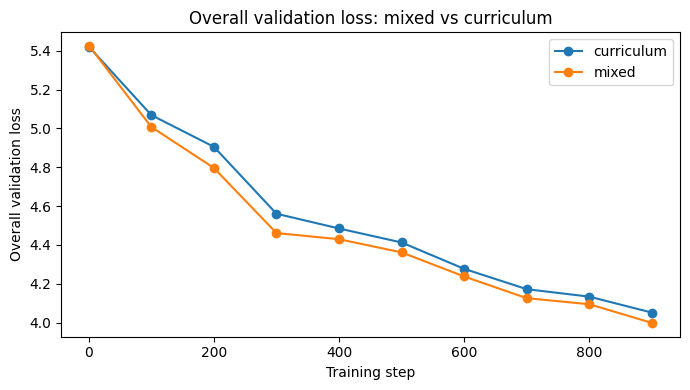

In [91]:
if not eval_df.empty:
    overall_df = eval_df[eval_df["eval_split"] == "overall"].copy()
    plt.figure(figsize=(7, 4))
    for condition, sub in overall_df.groupby("condition"):
        sub = sub.sort_values("step")
        plt.plot(sub["step"], sub["eval_loss"], marker="o", label=condition)
    plt.xlabel("Training step")
    plt.ylabel("Overall validation loss")
    plt.title("Overall validation loss: mixed vs curriculum")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "overall_validation_loss_curve.png", dpi=150)
    plt.show()
else:
    print("No evaluation log available yet.")


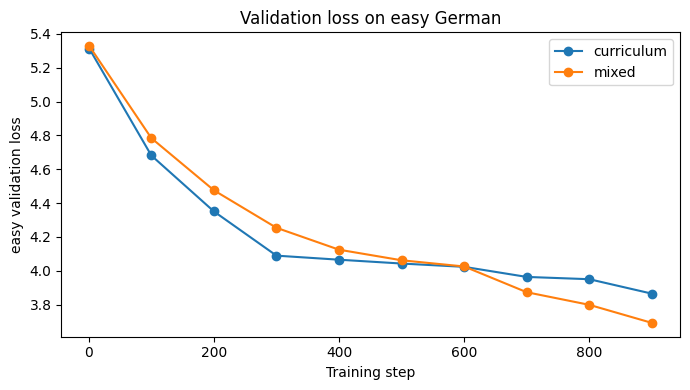

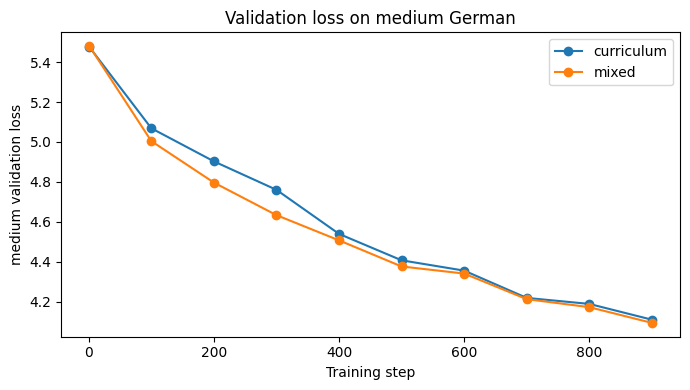

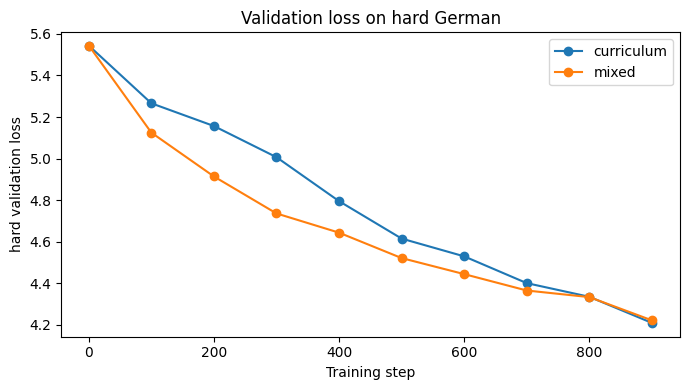

In [92]:
if not eval_df.empty:
    for split_name in ["easy", "medium", "hard"]:
        split_df = eval_df[eval_df["eval_split"] == split_name].copy()
        plt.figure(figsize=(7, 4))
        for condition, sub in split_df.groupby("condition"):
            sub = sub.sort_values("step")
            plt.plot(sub["step"], sub["eval_loss"], marker="o", label=condition)
        plt.xlabel("Training step")
        plt.ylabel(f"{split_name} validation loss")
        plt.title(f"Validation loss on {split_name} German")
        plt.legend()
        plt.tight_layout()
        plt.savefig(PLOT_DIR / f"{split_name}_validation_loss_curve.png", dpi=150)
        plt.show()
else:
    print("No evaluation log available yet.")


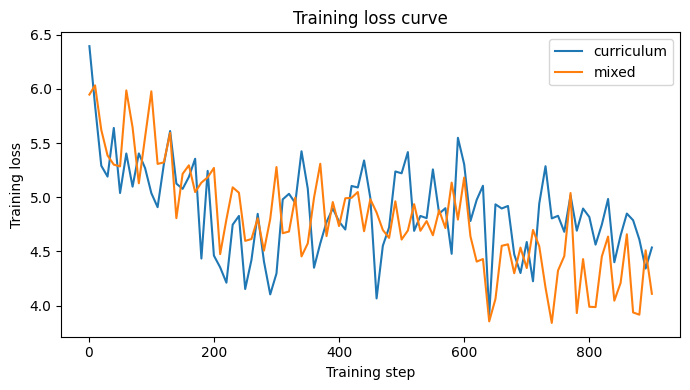

In [93]:
if not train_df.empty:
    plt.figure(figsize=(7, 4))
    for condition, sub in train_df.groupby("condition"):
        sub = sub.sort_values("step")
        plt.plot(sub["step"], sub["train_loss"], label=condition)
    plt.xlabel("Training step")
    plt.ylabel("Training loss")
    plt.title("Training loss curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "training_loss_curve.png", dpi=150)
    plt.show()
else:
    print("No training log available yet.")


In [94]:
if not eval_df.empty:
    final_rows = []
    for (condition, eval_split), sub in eval_df.groupby(["condition", "eval_split"]):
        sub = sub.sort_values("step")
        final_rows.append(sub.iloc[-1].to_dict())
    final_df = pd.DataFrame(final_rows)
    final_table = final_df.pivot(index="condition", columns="eval_split", values="eval_loss")
    ordered_cols = [c for c in ["easy", "medium", "hard", "overall"] if c in final_table.columns]
    final_table = final_table[ordered_cols]
    display(final_table)
    final_table.to_csv(LOG_DIR / "final_validation_loss_table.csv")
else:
    print("No evaluation log available yet.")


eval_split,easy,medium,hard,overall
condition,,,,
curriculum,3.865081,4.109911,4.210087,4.051270
mixed,3.692253,4.093896,4.222336,3.998293


# MVP v1.0 Conclusion and Result Analysis

## 1. Short Conclusion

MVP v1.0 successfully ran the intended comparison between a mixed-difficulty baseline and an easy-to-hard curriculum for German continued pretraining of a small English masked language model. However, the result does **not** support the main hypothesis that easy-to-hard curriculum training would clearly outperform mixed training under the same training budget.

The mixed baseline achieved lower final validation loss on the **easy**, **medium**, and **overall** validation sets. The curriculum model achieved a very small advantage only on the **hard** validation set. Therefore, the current result should be treated as a preliminary negative or mixed result rather than as evidence for a curriculum advantage.

## 2. Experimental Setup in MVP v1.0

The MVP used German4All as the only dataset and expanded the five readability levels into three difficulty groups:

| Group | Training examples | Validation examples |
|---|---:|---:|
| Easy | 45,828 | 5,090 |
| Medium | 22,914 | 2,545 |
| Hard | 45,828 | 5,090 |
| Total | 114,570 | 12,725 |

The model was `prajjwal1/bert-tiny` with the `bert-base-uncased` tokenizer. The training budget was 900 steps, batch size 8, max sequence length 128, MLM probability 0.15, and evaluation every 100 steps. Each validation split was evaluated with a maximum of 30 batches.

The two training conditions were:

| Condition | Training schedule |
|---|---|
| Mixed | mixed easy/medium/hard data for all 900 steps |
| Curriculum | steps 1–300 easy, 301–600 medium, 601–900 hard |

## 3. Final Validation Results

| Condition | Easy | Medium | Hard | Overall |
|---|---:|---:|---:|---:|
| Curriculum | 3.8651 | 4.1099 | **4.2101** | 4.0513 |
| Mixed | **3.6923** | **4.0939** | 4.2223 | **3.9983** |
| Curriculum - Mixed | +0.1728 | +0.0160 | -0.0122 | +0.0530 |

The final result shows three main patterns:

1. **Mixed is better overall.** The mixed baseline has lower final overall loss by about 0.053.
2. **Curriculum is worse on easy validation.** The easy split shows the largest gap, with curriculum worse by about 0.173.
3. **Curriculum is only slightly better on hard validation.** The hard-split advantage is very small, about 0.012, and should not be overinterpreted without repeated seeds.

## 4. Phase-Level Interpretation

The curriculum model did show phase-specific learning effects. During the easy phase, it improved faster on easy validation than the mixed baseline. During the medium and hard phases, it improved more strongly on the corresponding harder validation splits. This means the curriculum schedule was not meaningless: the model did react to the active training difficulty.

However, these local improvements did not accumulate into a better final overall model. The mixed baseline was more stable because it was exposed to the full difficulty distribution from the beginning. In contrast, the curriculum model delayed exposure to medium and hard data, and then had limited time to catch up.

## 5. Why the Result May Differ from the Hypothesis

### 5.1 The Mixed Baseline Is Stronger Than Expected

Mixed training is not equivalent to random noise. It exposes the model to easy, medium, and hard German from the beginning. Therefore, the model can adapt to basic German patterns while also learning from more difficult examples. This broad exposure may be more useful for MLM continued pretraining than a strict block curriculum.

### 5.2 The Current Curriculum Is Too Strict

The current curriculum is a hard block schedule: easy only, then medium only, then hard only. Human second-language learning usually includes replay: easier material remains present while more difficult material is gradually introduced. The current setup may therefore be too artificial.

### 5.3 Difficulty Exposure Is Not Fully Controlled

The expanded dataset has a natural ratio of approximately 40% easy, 20% medium, and 40% hard. The mixed baseline follows this ratio, but the curriculum uses equal step allocation: 33% easy, 33% medium, and 33% hard. This means the comparison does not isolate order alone; it also changes the amount of exposure to each difficulty group.

### 5.4 Readability Difficulty May Not Equal MLM Difficulty

German4All readability levels are designed for human readability, not necessarily for masked language modeling difficulty. MLM loss is also affected by token frequency, WordPiece fragmentation, sentence length, compound words, and tokenizer mismatch. A human-readable easy sentence may still be difficult for an English WordPiece tokenizer.

### 5.5 The Tokenizer Mismatch May Dominate the Curriculum Effect

The experiment deliberately uses an English uncased tokenizer. This creates a cross-lingual adaptation setting, but it also causes mismatch for German capitalization, compounds, umlauts, and morphology. The model may first need to deal with German tokenization artifacts before curriculum difficulty becomes useful.

### 5.6 The Pilot Is Small and Noisy

The experiment used only one seed, 900 training steps, a very small model, and limited validation batches. The hard-split curriculum advantage is extremely small, so it may disappear or reverse under another random seed.
